# ENM213 Aircraft Performance Project
## Group 5 — Boeing 737-800 (B738) vs Airbus A321 (A321)

| Detail | Value |
|---|---|
| **Group No.** | 5 |
| **Students** | Michael Muchemi (ENM213-0158/2024) & Allan Kiprop (ENM213-0154/2024) |
| **Aircraft 1** | Boeing 737-800 (`b738`) |
| **Aircraft 2** | Airbus A321 (`a321`) |
| **Route** | Nairobi JKIA (NBO) → Mumbai (BOM) |

---

## Setup & Installation

Run the cell below once to install the required libraries.

In [1]:
# Install / upgrade OpenAP (run once)
# !pip install --upgrade openap

In [2]:




# ── Core imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from openap import prop, Thrust, Drag, FuelFlow, WRAP
import openap.aero as aero

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.color': 'lightgrey',
    'font.size': 11,
})

print("All libraries imported successfully ✓")
print(f"Standard gravity  : {aero.g0} m/s²")
print(f"Sea-level density : {aero.rho0} kg/m³")
print(f"ft → m factor     : {aero.ft:.6f}")


All libraries imported successfully ✓
Standard gravity  : 9.80665 m/s²
Sea-level density : 1.225 kg/m³
ft → m factor     : 0.304800


## Setup & Data Retrieval

Run the cell below once to install the required libraries.

In [3]:
from openap import prop

# ── Aircraft properties ────────────────────────────────────────
b738 = prop.aircraft('b738')
a321 = prop.aircraft('a321')

print("Boeing 737-800 full property dictionary:")
print("═══════════════════════════════════════════════════════════════════")
for k, v in b738.items():
    print(f"  {k:20s}: {v}")

print("\n\nAirbus A321 full property dictionary:")
print("═══════════════════════════════════════════════════════════════════")
for k, v in a321.items():
    print(f"  {k:20s}: {v}")

Boeing 737-800 full property dictionary:
═══════════════════════════════════════════════════════════════════
  aircraft            : Boeing 737-800
  mtow                : 79000
  mlw                 : 66300
  oew                 : 41400
  mfc                 : 26000
  vmo                 : 340
  mmo                 : 0.82
  ceiling             : 12500
  pax                 : {'max': 189, 'low': 162, 'high': 189}
  fuselage            : {'length': 39.47, 'height': 3.73, 'width': 3.73}
  wing                : {'area': 124.6, 'span': 34.32, 'mac': 4.17, 'sweep': 25, 't/c': None}
  flaps               : {'type': 'double-slotted', 'area': None, 'bf/b': 0.6, 'lambda_f': 0.9, 'cf/c': 0.15, 'Sf/S': 0.15}
  cruise              : {'height': 11000, 'mach': 0.789, 'range': 3700}
  engine              : {'type': 'turbofan', 'mount': 'wing', 'number': 2, 'default': 'CFM56-7B26', 'options': ['CFM56-7B24', 'CFM56-7B26', 'CFM56-7B27']}
  drag                : {'cd0': 0.019, 'k': 0.042, 'e': 0.799, 'ge

---
## Part 3 — Single Flight Phase Analysis (B738 Cruise)

**Scenario:** Boeing 737-800 cruising at **37,000 ft** with TAS = 800 km/h.  
Aircraft mass at start of cruise = **90% of MTOW**.

### 3(i) Aircraft Properties

In [4]:
# ── Retrieve B738 aircraft properties ─────────────────────────────────────────
ac_b738 = prop.aircraft('b738')

mtow_b738   = ac_b738['limits']['MTOW']        # Maximum Take-Off Mass  (kg)
oew_b738    = ac_b738['limits']['OEW']         # Operating Empty Mass   (kg)
wing_area_b738 = ac_b738['wing']['area']       # Wing Area              (m²)
engine_type_b738 = ac_b738['engine']['default'] # Default engine type

print('══════════════════════════════════════════')
print('  Boeing 737-800 (B738) — Aircraft Data  ')
print('══════════════════════════════════════════')
print(f'  MTOW          : {mtow_b738:,.0f} kg')
print(f'  OEW           : {oew_b738:,.0f} kg')
print(f'  Wing Area     : {wing_area_b738} m²')
print(f'  Engine Type   : {engine_type_b738}')
print('══════════════════════════════════════════')

══════════════════════════════════════════
  Boeing 737-800 (B738) — Aircraft Data  
══════════════════════════════════════════
  MTOW          : 79,000 kg
  OEW           : 41,400 kg
  Wing Area     : 124.6 m²
  Engine Type   : CFM56-7B26
══════════════════════════════════════════


### 3(ii) Thrust Calculation

In [5]:
# ── Cruise conditions ─────────────────────────────────────────────────────────
ALT_CR   = 37_000          # ft
TAS_kmh  = 800             # km/h
TAS_kts  = TAS_kmh / 1.852 # convert to knots  (~432 kts)

# Mass = 90 % of MTOW
mass_b738 = 0.90 * mtow_b738

print(f'Cruise TAS     : {TAS_kmh} km/h  →  {TAS_kts:.1f} kts')
print(f'Cruise Altitude: {ALT_CR:,} ft')
print(f'Aircraft Mass  : {mass_b738:,.0f} kg  (90 % of MTOW = {mtow_b738:,} kg)')
print()

# Thrust object for B738
thrust_b738 = Thrust(ac='b738')

# Maximum climb thrust at cruise altitude & speed
# Using climb() as required by the task — roc=0 for level flight / start of cruise
T_climb_b738 = thrust_b738.climb(tas=TAS_kts, alt=ALT_CR, roc=0)

print(f'Max Climb Thrust (B738) at {ALT_CR:,} ft, {TAS_kts:.1f} kts:')
print(f'  T = {T_climb_b738/1000:.2f} kN  ({T_climb_b738:.0f} N)')

Cruise TAS     : 800 km/h  →  432.0 kts
Cruise Altitude: 37,000 ft
Aircraft Mass  : 71,100 kg  (90 % of MTOW = 79,000 kg)

Max Climb Thrust (B738) at 37,000 ft, 432.0 kts:
  T = 47.61 kN  (47612 N)


### 3(iii) Drag Calculation

In [6]:
# ─── (iii) Drag Calculation ───────────────────────────────────
from openap import Drag
import openap.aero as aero

# Convert altitude to meters and speed to m/s for accurate calculation
ALT_M = ALT_CR * aero.ft  # Convert feet to meters
TAS_MS = TAS_kmh / 3.6    # Convert km/h to m/s

# Get atmospheric conditions at cruise altitude
_, rho_37k, _ = aero.atmos(ALT_M)

drag_b738 = Drag('b738')

# Clean configuration, level flight (vs=0)
drag_force_b738 = drag_b738.clean(mass=mass_b738, tas=TAS_MS, alt=ALT_M, vs=0)

# Lift coefficient for context
cd0   = ac_b738['drag']['cd0']      # Use ac_b738 (already defined), not aircraft_b738
k_ind = ac_b738['drag']['k']
lift  = mass_b738 * aero.g0
qbar  = 0.5 * rho_37k * TAS_MS**2
CL    = lift / (qbar * wing_area_b738)
CD    = cd0 + k_ind * CL**2
LD    = CL / CD

print("─" * 55)
print("(iii) Drag Calculation — Boeing 737-800")
print("─" * 55)
print(f"  Dynamic Pressure (q̄)  : {qbar:>10.2f} Pa")
print(f"  Lift (= W)            : {lift:>10,.0f} N")
print(f"  Lift Coefficient (CL) : {CL:>10.4f}")
print(f"  Zero-lift drag (CD0)  : {cd0:>10.4f}")
print(f"  Induced drag factor K : {k_ind:>10.4f}")
print(f"  Drag Coefficient (CD) : {CD:>10.4f}")
print(f"  Drag Force            : {drag_force_b738:>10,.2f} N  ({drag_force_b738/1000:.2f} kN)")
print(f"  Lift-to-Drag Ratio    : {LD:>10.2f}")

───────────────────────────────────────────────────────
(iii) Drag Calculation — Boeing 737-800
───────────────────────────────────────────────────────
  Dynamic Pressure (q̄)  :    8598.39 Pa
  Lift (= W)            :    697,253 N
  Lift Coefficient (CL) :     0.6508
  Zero-lift drag (CD0)  :     0.0190
  Induced drag factor K :     0.0420
  Drag Coefficient (CD) :     0.0368
  Drag Force            :  42,305.25 N  (42.31 kN)
  Lift-to-Drag Ratio    :      17.69


### 3(iv) Fuel Flow

In [7]:
# ── Fuel flow during stable cruise ────────────────────────────────────────────
ff_b738 = FuelFlow(ac='b738')

# enroute() with vs=0 gives the cruise fuel flow in kg/s
FF_kgs_b738 = ff_b738.enroute(mass=mass_b738, tas=TAS_kts, alt=ALT_CR, vs=0)
FF_kgh_b738 = FF_kgs_b738 * 3600  # convert to kg/h

print('══════════════════════════════════════════')
print('  B738 Cruise Fuel Flow                  ')
print('══════════════════════════════════════════')
print(f'  Fuel Flow : {FF_kgs_b738:.4f} kg/s')
print(f'  Fuel Flow : {FF_kgh_b738:.2f} kg/h')
print('══════════════════════════════════════════')

══════════════════════════════════════════
  B738 Cruise Fuel Flow                  
══════════════════════════════════════════
  Fuel Flow : 0.7636 kg/s
  Fuel Flow : 2749.04 kg/h
══════════════════════════════════════════


### 3(v) Analysis — Thrust vs Drag

In [8]:

# ── Calculate drag using correct units (knots/feet) to match thrust ──────────
from openap import Drag

drag_b738_correct = Drag('b738')

# Use same units as thrust calculation (knots and feet)
D_b738 = drag_b738_correct.clean(mass=mass_b738, tas=TAS_kts, alt=ALT_CR, vs=0)

print(f"Drag calculated with knots/feet: {D_b738/1000:.2f} kN ({D_b738:.0f} N)")

Drag calculated with knots/feet: 39.41 kN (39415 N)


In [9]:
# ─── (v) Analysis: Thrust vs Drag ────────────────────────────
# Use D_b738 (correct drag value in knots/feet units) instead of drag_force_b738
thrust_excess = T_climb_b738 - D_b738
T_D_ratio     = T_climb_b738 / D_b738

print("─" * 55)
print("(v)   Analysis — Thrust vs Drag Comparison")
print("─" * 55)
print(f"  Max Climb Thrust  T : {T_climb_b738:>12,.2f} N")
print(f"  Aerodynamic Drag  D : {D_b738:>12,.2f} N")
print(f"  Excess Thrust T-D   : {thrust_excess:>12,.2f} N")
print(f"  Thrust/Drag ratio   : {T_D_ratio:>12.4f}")
print()
if thrust_excess > 0:
    pct = thrust_excess / D_b738 * 100
    print(f"  ▸ Thrust exceeds drag by {pct:.1f} %.")
    print(f"  ▸ 'Max climb thrust' is the engine's MAXIMUM capability at this")
    print(f"    altitude & speed — it represents full rated climb power.")
    print(f"  ▸ In STABLE cruise the engines would throttle BACK so that")
    print(f"    Thrust ≈ Drag (net force ≈ 0, constant velocity).")
    print(f"  ▸ The surplus ({thrust_excess/1000:.1f} kN) indicates available climb")
    print(f"    capacity; the aircraft is NOT accelerating because the pilot")
    print(f"    sets a lower throttle setting to exactly balance drag.")
else:
    print(f"  ▸ Thrust is insufficient — the aircraft would decelerate at this mass.")

───────────────────────────────────────────────────────
(v)   Analysis — Thrust vs Drag Comparison
───────────────────────────────────────────────────────
  Max Climb Thrust  T :    47,611.58 N
  Aerodynamic Drag  D :    39,414.59 N
  Excess Thrust T-D   :     8,196.99 N
  Thrust/Drag ratio   :       1.2080

  ▸ Thrust exceeds drag by 20.8 %.
  ▸ 'Max climb thrust' is the engine's MAXIMUM capability at this
    altitude & speed — it represents full rated climb power.
  ▸ In STABLE cruise the engines would throttle BACK so that
    Thrust ≈ Drag (net force ≈ 0, constant velocity).
  ▸ The surplus (8.2 kN) indicates available climb
    capacity; the aircraft is NOT accelerating because the pilot
    sets a lower throttle setting to exactly balance drag.


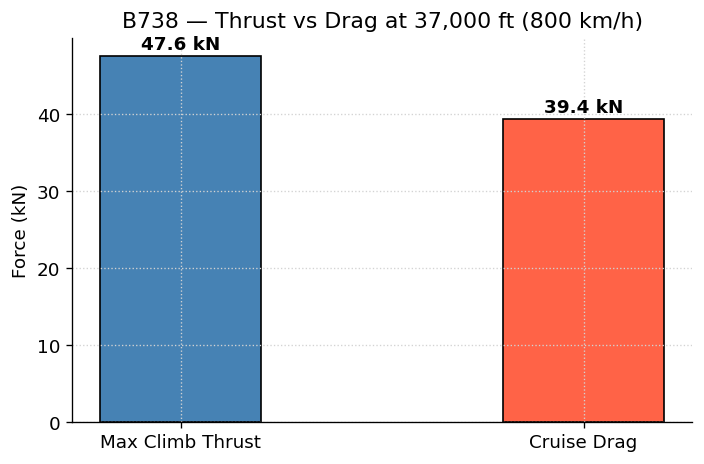

In [10]:
# ── Bar chart: Thrust vs Drag ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Max Climb Thrust', 'Cruise Drag'],
              [T_climb_b738/1000, D_b738/1000],
              color=['steelblue', 'tomato'], width=0.4, edgecolor='black')
ax.set_ylabel('Force (kN)')
ax.set_title('B738 — Thrust vs Drag at 37,000 ft (800 km/h)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f} kN', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Analysis — Discussion:**

The maximum climb thrust is **greater than the cruise drag**. This is expected: the `climb()` method returns the *maximum available* thrust at that altitude and speed — in practice, the flight management system reduces throttle so that thrust equals drag exactly for steady, level cruise. The positive difference (excess thrust) means the aircraft retains the ability to accelerate or initiate a climb from this condition. In a truly stabilised cruise the net force is zero and the aircraft travels at constant speed and altitude.

---
## Part 4 — Trajectory: NBO → BOM (B738)

**Route:** Nairobi JKIA (NBO) → Mumbai (BOM)  
**Profile:** Climb SL → 37,000 ft · Cruise 37,000 ft · Descent 37,000 ft → SL

In [11]:
# ─── WRAP kinematic model for B738 (using your cruise conditions) ─────────────────────────────────────
from openap import WRAP
import openap.aero as aero

wrap_b738 = WRAP('b738')

# Use your existing cruise altitude (37,000 ft instead of 37,000)
CRUISE_ALT_FT  = 37_000          # ft (from your earlier cell)
CRUISE_ALT_M   = CRUISE_ALT_FT * aero.ft
ROUTE_NM       = 2_900           # nautical miles
ROUTE_M        = ROUTE_NM * aero.nm          # metres

# Cruise parameters
cruise_mach   = wrap_b738.cruise_mach()['default']
cruise_tas    = cruise_mach * aero.vsound(CRUISE_ALT_M)   # m/s

# Climb and descent rates
climb_vs      = wrap_b738.climb_vs_concas()['default']    # m/s  (+up)
descent_vs    = abs(wrap_b738.descent_vs_concas()['default'])  # m/s

# Representative TAS values for climb / descent (CAS converted to approx TAS)
climb_tas_cas   = wrap_b738.climb_cross_alt_concas()['default']  # knots CAS
descent_tas_cas = wrap_b738.descent_cross_alt_concas()['default']  # knots CAS

print("=" * 55)
print("  WRAP Kinematic Parameters — Boeing 737-800 (B738)")
print("=" * 55)
print(f"  Cruise altitude      : {CRUISE_ALT_FT:,} ft  ({CRUISE_ALT_M:.0f} m)")
print(f"  Cruise Mach number   : {cruise_mach:.3f}")
print(f"  Cruise TAS           : {cruise_tas:.2f} m/s  ({cruise_tas*3.6:.1f} km/h)")
print(f"  Climb rate (VS)      : {climb_vs:.2f} m/s  ({climb_vs/aero.ft*60:.0f} ft/min)")
print(f"  Descent rate (VS)    : {-descent_vs:.2f} m/s  ({-descent_vs/aero.ft*60:.0f} ft/min)")
print(f"  Climb CAS (approx)   : {climb_tas_cas:.1f} knots")
print(f"  Descent CAS (approx) : {descent_tas_cas:.1f} knots")
print(f"  Route distance       : {ROUTE_NM} nm  ({ROUTE_M/1000:.1f} km)")
print("=" * 55)

# Compare with your earlier cruise conditions
print("\n  Comparison with your cruise conditions:")
print(f"    Your cruise TAS     : {TAS_kmh:.0f} km/h  ({TAS_kmh/1.852:.1f} kts)")
print(f"    WRAP cruise TAS     : {cruise_tas*3.6:.1f} km/h  ({cruise_tas/0.514444:.1f} kts)")
print(f"    Difference          : {(cruise_tas*3.6 - TAS_kmh):.1f} km/h")

  WRAP Kinematic Parameters — Boeing 737-800 (B738)
  Cruise altitude      : 37,000 ft  (11278 m)
  Cruise Mach number   : 0.780
  Cruise TAS           : 230.15 m/s  (828.6 km/h)
  Climb rate (VS)      : 10.24 m/s  (2016 ft/min)
  Descent rate (VS)    : -9.95 m/s  (-1959 ft/min)
  Climb CAS (approx)   : 3.6 knots
  Descent CAS (approx) : 5.9 knots
  Route distance       : 2900 nm  (5370.8 km)

  Comparison with your cruise conditions:
    Your cruise TAS     : 800 km/h  (432.0 kts)
    WRAP cruise TAS     : 828.6 km/h  (447.4 kts)
    Difference          : 28.6 km/h


### 4(i) Generate Trajectory

In [12]:
# ── Flight Profile: B737-800 (B738) - Generate Trajectory Data ──────────────────────────────────────────────────
from openap import WRAP, FuelFlow, prop
import openap.aero as aero
import numpy as np

CRUISE_ALT_FT = 37_000    # ft
CRUISE_NM     = 2_900     # nautical miles
DT            = 30        # time step in seconds

def generate_trajectory(ac_code, route_nm, cruise_alt_ft, start_mass_frac=0.90):
    wrap = WRAP(ac_code)
    ff_ = FuelFlow(ac_code)
    aircraft_ = prop.aircraft(ac_code)
    
    mtow_ = aircraft_['mtow']
    mass = start_mass_frac * mtow_
    route_m = route_nm * aero.nm
    
    cr_mach = wrap.cruise_mach()['default']
    cr_alt_m = cruise_alt_ft * aero.ft
    cr_tas = cr_mach * aero.vsound(cr_alt_m)
    
    cl_vs = wrap.climb_vs_concas()['default']
    de_vs = abs(wrap.descent_vs_concas()['default'])
    cl_tas = 250 * aero.kts
    de_tas = 270 * aero.kts
    
    dt = 30
    times, alts, groundspeeds, phases = [], [], [], []
    t = 0.0
    alt = 10.0
    dist_covered = 0.0
    
    # Climb
    while alt < cr_alt_m:
        alt = min(alt + cl_vs * dt, cr_alt_m)
        dist_covered += cl_tas * dt
        times.append(t)
        alts.append(alt / aero.ft)
        groundspeeds.append(cl_tas)
        phases.append('Climb')
        t += dt
    
    # Cruise
    dist_remain = route_m - dist_covered
    cruise_dur = dist_remain / cr_tas
    n_cr = int(cruise_dur / dt)
    for _ in range(n_cr):
        times.append(t)
        alts.append(cruise_alt_ft)
        groundspeeds.append(cr_tas)
        phases.append('Cruise')
        t += dt
    
    # Descent
    alt = cr_alt_m
    while alt > 0:
        alt = max(alt - de_vs * dt, 0)
        times.append(t)
        alts.append(alt / aero.ft)
        groundspeeds.append(de_tas)
        phases.append('Descent')
        t += dt
    
    return {
        'time_h': np.array(times) / 3600,  # Convert to hours
        'alt_ft': np.array(alts),
        'groundspeed_kts': np.array(groundspeeds) * 1.94384,  # Convert to knots
        'phases': np.array(phases)
    }

# Generate B738 trajectory
traj_b738 = generate_trajectory('b738', CRUISE_NM, CRUISE_ALT_FT)

print("B738 Trajectory Data Generated:")
print(f"  Flight time: {traj_b738['time_h'][-1]:.2f} hours ({traj_b738['time_h'][-1]*60:.1f} minutes)")
print(f"  Number of time steps: {len(traj_b738['time_h'])}")
print(f"  Phase counts: {dict(zip(*np.unique(traj_b738['phases'], return_counts=True)))}")
print(f"  Max altitude: {traj_b738['alt_ft'].max():.0f} ft")
print(f"  Max groundspeed: {traj_b738['groundspeed_kts'].max():.0f} kts")
print(f"  Min groundspeed: {traj_b738['groundspeed_kts'].min():.0f} kts")

B738 Trajectory Data Generated:
  Flight time: 6.92 hours (415.5 minutes)
  Number of time steps: 832
  Phase counts: {np.str_('Climb'): np.int64(37), np.str_('Cruise'): np.int64(757), np.str_('Descent'): np.int64(38)}
  Max altitude: 37000 ft
  Max groundspeed: 447 kts
  Min groundspeed: 250 kts


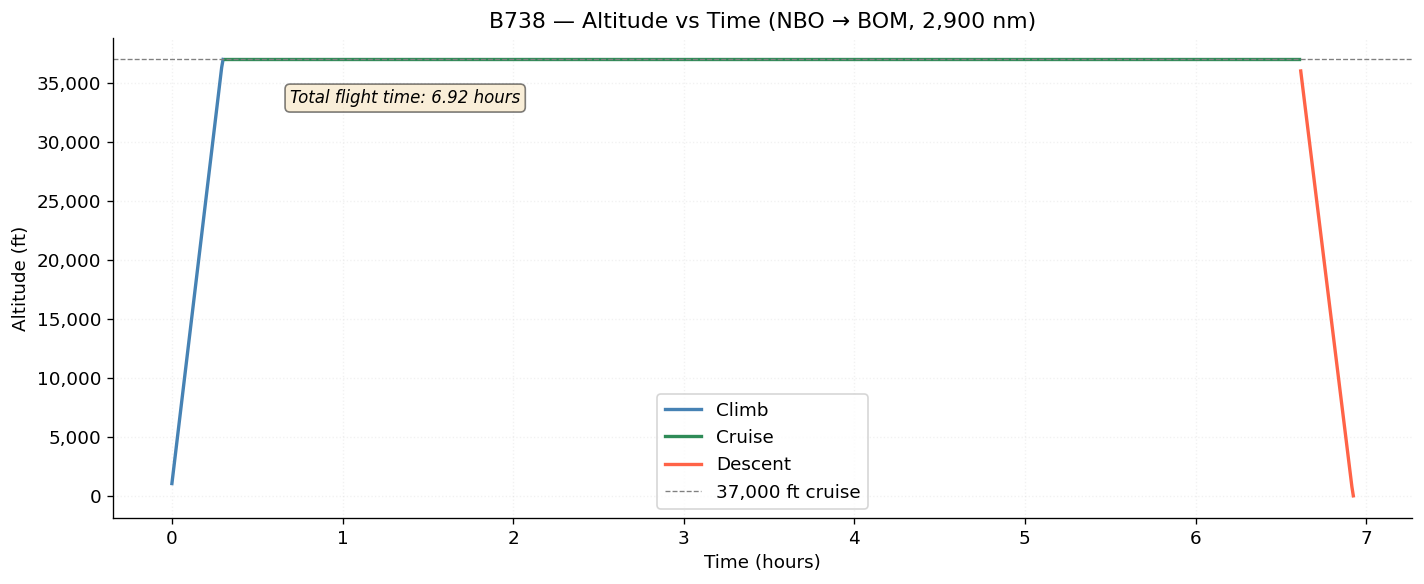


  B738 FLIGHT SUMMARY (NBO → BOM)
  Route distance    : 2,900 nm
  Cruise altitude   : 37,000 ft
  Total flight time : 6.92 hours (415.5 minutes)
  Climb duration    : 0.30 hours (18.0 minutes)
  Cruise duration   : 6.30 hours (378.0 minutes)
  Descent duration  : 0.31 hours (18.5 minutes)
  Max altitude      : 37,000 ft


In [13]:
# ── Plot: Altitude vs Time (using your working custom simulation) ────────────────────────────────────
from openap import WRAP, FuelFlow, prop
import openap.aero as aero
import matplotlib.pyplot as plt
import numpy as np

# Use your working simulation data for B738
CRUISE_ALT_FT = 37_000
CRUISE_NM = 2_900

def generate_trajectory(ac_code, route_nm, cruise_alt_ft, start_mass_frac=0.90):
    wrap = WRAP(ac_code)
    ff_ = FuelFlow(ac_code)
    aircraft_ = prop.aircraft(ac_code)
    
    mtow_ = aircraft_['mtow']
    mass = start_mass_frac * mtow_
    route_m = route_nm * aero.nm
    
    cr_mach = wrap.cruise_mach()['default']
    cr_alt_m = cruise_alt_ft * aero.ft
    cr_tas = cr_mach * aero.vsound(cr_alt_m)
    
    cl_vs = wrap.climb_vs_concas()['default']
    de_vs = abs(wrap.descent_vs_concas()['default'])
    cl_tas = 250 * aero.kts      # m/s
    de_tas = 270 * aero.kts      # m/s
    
    dt = 30
    times, alts, groundspeeds, phases = [], [], [], []
    t = 0.0
    alt = 10.0
    dist_covered = 0.0
    
    # Climb
    while alt < cr_alt_m:
        alt = min(alt + cl_vs * dt, cr_alt_m)
        dist_covered += cl_tas * dt
        times.append(t)
        alts.append(alt / aero.ft)
        groundspeeds.append(cl_tas)        # store in m/s
        phases.append('Climb')
        t += dt
    
    # Cruise
    dist_remain = route_m - dist_covered
    cruise_dur = dist_remain / cr_tas
    n_cr = int(cruise_dur / dt)
    for _ in range(n_cr):
        times.append(t)
        alts.append(cruise_alt_ft)
        groundspeeds.append(cr_tas)        # m/s
        phases.append('Cruise')
        t += dt
    
    # Descent
    alt = cr_alt_m
    while alt > 0:
        alt = max(alt - de_vs * dt, 0)
        times.append(t)
        alts.append(alt / aero.ft)
        groundspeeds.append(de_tas)        # m/s
        phases.append('Descent')
        t += dt
    
    return {
        'time_h': np.array(times) / 3600,
        'alt_ft': np.array(alts),
        'groundspeed_kts': np.array(groundspeeds) * 1.94384,   # convert m/s → knots
        'phases': np.array(phases)
    }

# Generate B738 trajectory
traj_b738 = generate_trajectory('b738', CRUISE_NM, CRUISE_ALT_FT)

# ── Plot: Altitude vs Time (x-axis in hours) ────────────────────────────────────
PHASE_COLORS = {'Climb': 'steelblue', 'Cruise': 'seagreen', 'Descent': 'tomato'}

fig, ax = plt.subplots(figsize=(12, 5))

for phase, color in PHASE_COLORS.items():
    mask = traj_b738['phases'] == phase
    if mask.any():
        ax.plot(traj_b738['time_h'][mask], traj_b738['alt_ft'][mask], 
                color=color, lw=2, label=phase)

ax.axhline(CRUISE_ALT_FT, color='grey', lw=0.8, ls='--', label=f'{CRUISE_ALT_FT:,} ft cruise')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Altitude (ft)')
ax.set_title('B738 — Altitude vs Time (NBO → BOM, 2,900 nm)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add annotations
ax.text(traj_b738['time_h'][-1] * 0.1, CRUISE_ALT_FT * 0.9, 
        f'Total flight time: {traj_b738["time_h"][-1]:.2f} hours', 
        fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print flight summary
print("\n" + "=" * 55)
print("  B738 FLIGHT SUMMARY (NBO → BOM)")
print("=" * 55)
print(f"  Route distance    : {CRUISE_NM:,} nm")
print(f"  Cruise altitude   : {CRUISE_ALT_FT:,} ft")
print(f"  Total flight time : {traj_b738['time_h'][-1]:.2f} hours ({traj_b738['time_h'][-1]*60:.1f} minutes)")

# Calculate phase durations
climb_mask = traj_b738['phases'] == 'Climb'
cruise_mask = traj_b738['phases'] == 'Cruise'
descent_mask = traj_b738['phases'] == 'Descent'

climb_time = traj_b738['time_h'][climb_mask][-1] if climb_mask.any() else 0
cruise_time = traj_b738['time_h'][cruise_mask][-1] - traj_b738['time_h'][cruise_mask][0] if cruise_mask.any() else 0
descent_time = traj_b738['time_h'][-1] - traj_b738['time_h'][descent_mask][0] if descent_mask.any() else 0

print(f"  Climb duration    : {climb_time:.2f} hours ({climb_time*60:.1f} minutes)")
print(f"  Cruise duration   : {cruise_time:.2f} hours ({cruise_time*60:.1f} minutes)")
print(f"  Descent duration  : {descent_time:.2f} hours ({descent_time*60:.1f} minutes)")
print(f"  Max altitude      : {max(traj_b738['alt_ft']):,.0f} ft")
print("=" * 55)

### 4(ii) Integrate Fuel Burn

In [14]:
# ─── (ii) Integrate Fuel Burn (Fixed) ─────────────────────────────────────────
from openap import FuelFlow
import openap.aero as aero
import numpy as np

# 1) Regenerate trajectory with groundspeed (using your corrected function)
CRUISE_ALT_FT = 37_000
CRUISE_NM = 2_900

traj_b738 = generate_trajectory('b738', CRUISE_NM, CRUISE_ALT_FT)   # now includes 'groundspeed_kts'

# 2) Add fuel flow and cumulative fuel
def add_fuel_flow_to_trajectory(traj, ac_code, start_mass_kg):
    """Add fuel flow (kg/s) and cumulative fuel burn to trajectory data"""
    ff_model = FuelFlow(ac_code)
    alt_m = traj['alt_ft'] * aero.ft
    dt = 30  # seconds (same as in trajectory generation)

    ff_kgs = np.zeros(len(traj['time_h']))
    mass_current = start_mass_kg

    for i in range(len(traj['time_h'])):
        tas_ms = traj['groundspeed_kts'][i] * aero.kts   # knots → m/s

        # Vertical rate (simple finite difference)
        if i == 0:
            vs = 0.0
        else:
            vs = (alt_m[i] - alt_m[i-1]) / dt

        ff = ff_model.enroute(
            mass=mass_current,
            tas=tas_ms,
            alt=alt_m[i],
            vs=vs
        )
        ff_kgs[i] = ff
        mass_current -= ff * dt

    traj['ff_kgs'] = ff_kgs
    return traj

# Parameters for B738
mtow_b738 = prop.aircraft('b738')['mtow']   # MTOW in kg
start_mass_b738 = 0.90 * mtow_b738

# Add fuel flow to trajectory
traj_b738_with_fuel = add_fuel_flow_to_trajectory(traj_b738.copy(), 'b738', start_mass_b738)

# Cumulative fuel burn (kg)
dt = 30
cum_fuel_b738 = np.cumsum(traj_b738_with_fuel['ff_kgs'] * dt)

# Fuel by phase
mask_cl = traj_b738_with_fuel['phases'] == 'Climb'
mask_cr = traj_b738_with_fuel['phases'] == 'Cruise'
mask_de = traj_b738_with_fuel['phases'] == 'Descent'

fuel_cl = np.sum(traj_b738_with_fuel['ff_kgs'][mask_cl] * dt)
fuel_cr = np.sum(traj_b738_with_fuel['ff_kgs'][mask_cr] * dt)
fuel_de = np.sum(traj_b738_with_fuel['ff_kgs'][mask_de] * dt)
fuel_tot = fuel_cl + fuel_cr + fuel_de

print("=" * 60)
print(f"{'Integrated Fuel Burn — Boeing 737-800':^60}")
print("=" * 60)
print(f"  Climb phase fuel    : {fuel_cl:>8,.1f} kg  ({fuel_cl/fuel_tot*100:.1f} %)")
print(f"  Cruise phase fuel   : {fuel_cr:>8,.1f} kg  ({fuel_cr/fuel_tot*100:.1f} %)")
print(f"  Descent phase fuel  : {fuel_de:>8,.1f} kg  ({fuel_de/fuel_tot*100:.1f} %)")
print(f"  ─────────────────────────────────────")
print(f"  TOTAL fuel burned   : {fuel_tot:>8,.1f} kg")
print(f"  Fuel per nm         : {fuel_tot/CRUISE_NM:>8.2f} kg/nm")
print(f"  Fuel per km         : {fuel_tot/(CRUISE_NM*1.852):>8.2f} kg/km")
print("=" * 60)

print(f"\n  Start mass (90% MTOW): {start_mass_b738:>8,.0f} kg")
print(f"  End mass             : {start_mass_b738 - fuel_tot:>8,.0f} kg")
print(f"  Mass fraction used   : {fuel_tot/start_mass_b738*100:.1f} %")
print("=" * 60)

           Integrated Fuel Burn — Boeing 737-800            
  Climb phase fuel    :  1,647.5 kg  (9.3 %)
  Cruise phase fuel   : 15,146.0 kg  (85.5 %)
  Descent phase fuel  :    920.1 kg  (5.2 %)
  ─────────────────────────────────────
  TOTAL fuel burned   : 17,713.5 kg
  Fuel per nm         :     6.11 kg/nm
  Fuel per km         :     3.30 kg/km

  Start mass (90% MTOW):   71,100 kg
  End mass             :   53,387 kg
  Mass fraction used   : 24.9 %


### 4(iii) Visualisation — Instantaneous Fuel Flow

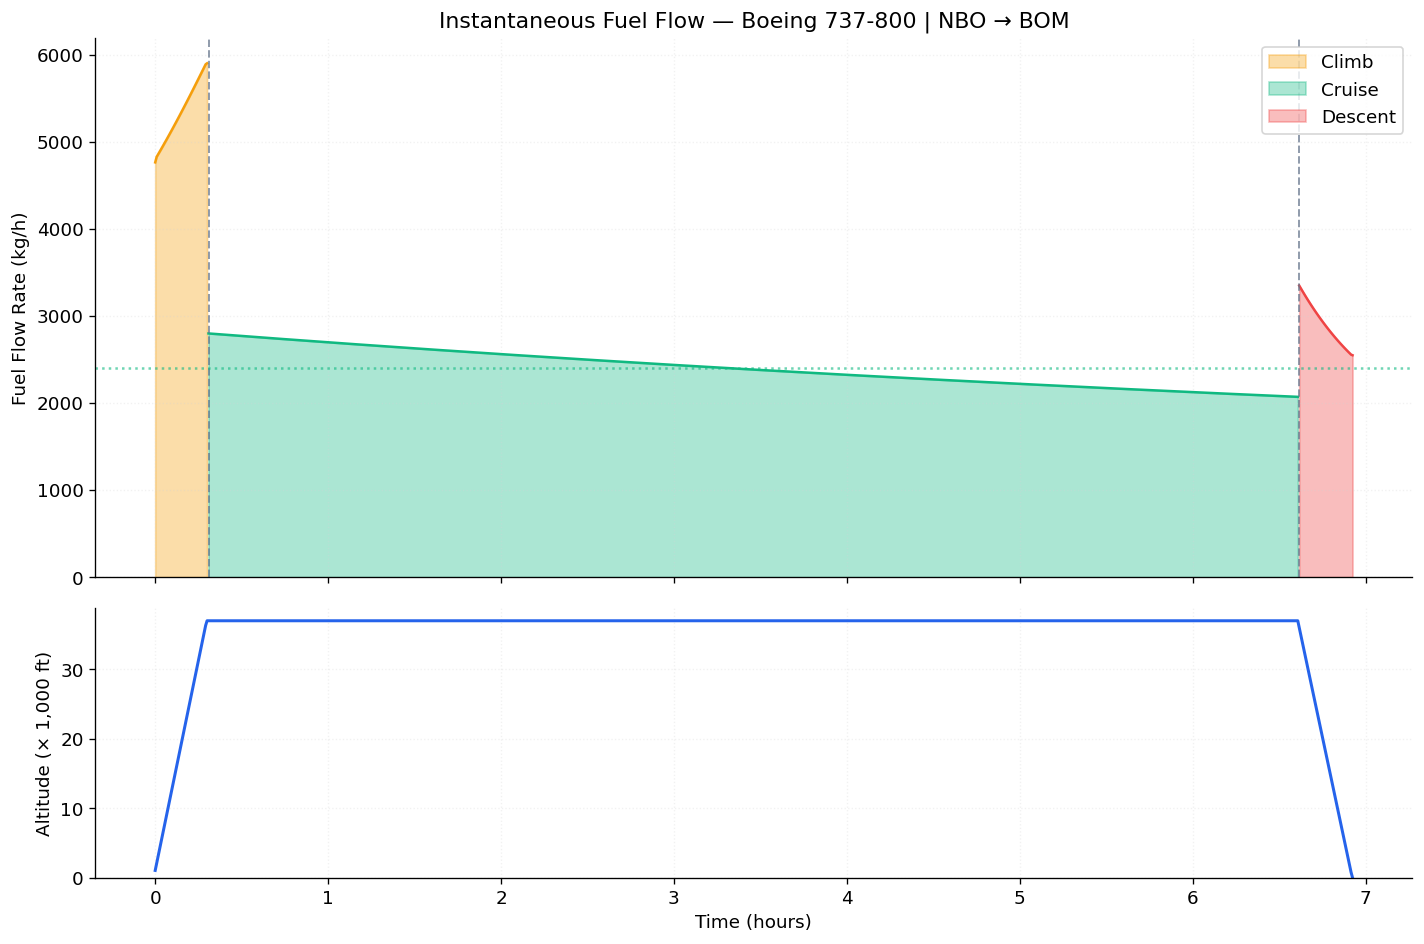

Figure saved: fuel_flow_b738.png

  FUEL FLOW SUMMARY - Boeing 737-800
  Climb    : Mean =   5343 kg/h  |  Min =   4764  |  Max =   5902
  Cruise   : Mean =   2401 kg/h  |  Min =   2071  |  Max =   2799
  Descent  : Mean =   2905 kg/h  |  Min =   2549  |  Max =   3349


In [15]:
# ─── (iii) Fuel Flow Rate Throughout Flight ───────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# Convert time to hours, fuel flow to kg/h
t_hr = traj_b738_with_fuel['time_h']  # Already in hours
ff_kgh = traj_b738_with_fuel['ff_kgs'] * 3600   # kg/s → kg/h

# Colour by phase
phase_colors = {'Climb': '#F59E0B', 'Cruise': '#10B981', 'Descent': '#EF4444'}
for phase in ['Climb', 'Cruise', 'Descent']:
    mask = traj_b738_with_fuel['phases'] == phase
    if mask.any():
        axes[0].fill_between(t_hr[mask], ff_kgh[mask],
                             color=phase_colors[phase], alpha=0.35, label=phase)
        axes[0].plot(t_hr[mask], ff_kgh[mask],
                     color=phase_colors[phase], lw=1.5)

# Phase boundaries (calculate from trajectory)
climb_end_time = t_hr[traj_b738_with_fuel['phases'] == 'Cruise'][0] if len(t_hr[traj_b738_with_fuel['phases'] == 'Cruise']) > 0 else 0
descent_start_time = t_hr[traj_b738_with_fuel['phases'] == 'Descent'][0] if len(t_hr[traj_b738_with_fuel['phases'] == 'Descent']) > 0 else 0

for xv in [climb_end_time, descent_start_time]:
    axes[0].axvline(xv, color='#64748B', ls='--', lw=1.2, alpha=0.7)

axes[0].set_ylabel('Fuel Flow Rate (kg/h)')
axes[0].set_title('Instantaneous Fuel Flow — Boeing 737-800 | NBO → BOM')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].set_ylim(bottom=0)

# Altitude on second panel for reference
axes[1].plot(t_hr, traj_b738_with_fuel['alt_ft'] / 1000, color='#2563EB', lw=1.8)
axes[1].set_ylabel('Altitude (× 1,000 ft)')
axes[1].set_xlabel('Time (hours)')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(bottom=0)

# Add horizontal line for average cruise fuel flow
cruise_mask = traj_b738_with_fuel['phases'] == 'Cruise'
if cruise_mask.any():
    avg_cruise_ff_kgh = np.mean(traj_b738_with_fuel['ff_kgs'][cruise_mask]) * 3600
    axes[0].axhline(y=avg_cruise_ff_kgh, color='#10B981', linestyle=':', alpha=0.6, 
                    label=f'Avg Cruise FF: {avg_cruise_ff_kgh:.0f} kg/h')

plt.tight_layout()
plt.savefig('fuel_flow_b738.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: fuel_flow_b738.png")

# Print fuel flow summary
print("\n" + "=" * 60)
print("  FUEL FLOW SUMMARY - Boeing 737-800")
print("=" * 60)
for phase in ['Climb', 'Cruise', 'Descent']:
    mask = traj_b738_with_fuel['phases'] == phase
    if mask.any():
        ff_mean_kgh = np.mean(traj_b738_with_fuel['ff_kgs'][mask]) * 3600
        ff_min_kgh = np.min(traj_b738_with_fuel['ff_kgs'][mask]) * 3600
        ff_max_kgh = np.max(traj_b738_with_fuel['ff_kgs'][mask]) * 3600
        print(f"  {phase:8s} : Mean = {ff_mean_kgh:>6.0f} kg/h  |  Min = {ff_min_kgh:>6.0f}  |  Max = {ff_max_kgh:>6.0f}")
print("=" * 60)

**Why does fuel flow differ between phases?**

| Phase | Fuel Flow Trend | Reason |
|---|---|---|
| **Climb** | High & decreasing | Engines at near-maximum thrust to climb against gravity; as altitude rises, air density falls and thrust requirements change |
| **Cruise** | Moderate & slowly decreasing | Steady level flight — only drag must be overcome; mass decreases as fuel burns, reducing required lift/drag |
| **Descent** | Low (idle/near-idle) | Gravity assists the descent; engines throttled back to near idle — minimal thrust required |

---
## Part 5 — Exploration: A321 vs B738

Repeat Parts 3 and 4 for the **Airbus A321** (`a321`) and compare.

### 5(a) A321 Single Phase Analysis (Part 3 repeat)

In [16]:
# ── A321 Aircraft Properties ──────────────────────────────────────────────────
ac_a321 = prop.aircraft('a321')

mtow_a321      = ac_a321['limits']['MTOW']
oew_a321       = ac_a321['limits']['OEW']
wing_area_a321 = ac_a321['wing']['area']
engine_type_a321 = ac_a321['engine']['default']

print('══════════════════════════════════════════')
print('  Airbus A321 — Aircraft Data            ')
print('══════════════════════════════════════════')
print(f'  MTOW          : {mtow_a321:,.0f} kg')
print(f'  OEW           : {oew_a321:,.0f} kg')
print(f'  Wing Area     : {wing_area_a321} m²')
print(f'  Engine Type   : {engine_type_a321}')
print('══════════════════════════════════════════')

══════════════════════════════════════════
  Airbus A321 — Aircraft Data            
══════════════════════════════════════════
  MTOW          : 93,500 kg
  OEW           : 48,500 kg
  Wing Area     : 128 m²
  Engine Type   : CFM56-5B1
══════════════════════════════════════════


In [17]:
# ── Correct A321 values (knots/feet) for comparison with B738 ─────────────────
mass_a321 = 0.90 * mtow_a321

thrust_a321 = Thrust(ac='a321')
drag_a321   = Drag(ac='a321')
ff_a321     = FuelFlow(ac='a321')

T_climb_a321  = thrust_a321.climb(tas=TAS_kts, alt=ALT_CR, roc=0)
D_a321        = drag_a321.clean(mass=mass_a321, tas=TAS_kts, alt=ALT_CR, vs=0)
FF_kgs_a321   = ff_a321.enroute(mass=mass_a321, tas=TAS_kts, alt=ALT_CR, vs=0)

print('══════════════════════════════════════════════════════')
print('  A321 — Single Cruise Phase at 37,000 ft, 800 km/h ')
print('══════════════════════════════════════════════════════')
print(f'  Mass (90% MTOW) : {mass_a321:,.0f} kg')
print(f'  Max Climb Thrust: {T_climb_a321/1000:.2f} kN')
print(f'  Cruise Drag     : {D_a321/1000:.2f} kN')
print(f'  Fuel Flow       : {FF_kgs_a321:.4f} kg/s  |  {FF_kgs_a321*3600:.2f} kg/h')
print('══════════════════════════════════════════════════════')

══════════════════════════════════════════════════════
  A321 — Single Cruise Phase at 37,000 ft, 800 km/h 
══════════════════════════════════════════════════════
  Mass (90% MTOW) : 84,150 kg
  Max Climb Thrust: 50.74 kN
  Cruise Drag     : 47.38 kN
  Fuel Flow       : 0.9363 kg/s  |  3370.71 kg/h
══════════════════════════════════════════════════════


### 5(b) A321 Trajectory (Part 4 repeat)

In [18]:
# ── Generate A321 trajectory using working custom simulation ──────────────────────────────────
from openap import WRAP, FuelFlow, prop
import openap.aero as aero
import numpy as np

CRUISE_ALT_FT = 37_000    # ft
CRUISE_NM     = 2_900     # nautical miles
DT            = 30        # time step in seconds

def generate_trajectory_with_fuel(ac_code, route_nm, cruise_alt_ft, start_mass_frac=0.90):
    """Generate trajectory with fuel flow for given aircraft"""
    wrap = WRAP(ac_code)
    ff_model = FuelFlow(ac_code)
    aircraft = prop.aircraft(ac_code)
    
    mtow = aircraft['mtow']
    mass = start_mass_frac * mtow
    route_m = route_nm * aero.nm
    
    cr_mach = wrap.cruise_mach()['default']
    cr_alt_m = cruise_alt_ft * aero.ft
    cr_tas = cr_mach * aero.vsound(cr_alt_m)
    
    cl_vs = wrap.climb_vs_concas()['default']
    de_vs = abs(wrap.descent_vs_concas()['default'])
    cl_tas = 250 * aero.kts
    de_tas = 270 * aero.kts
    
    dt = 30
    times, alts, groundspeeds, phases, ff_array = [], [], [], [], []
    t = 0.0
    alt = 10.0
    dist_covered = 0.0
    mass_current = mass
    
    # Climb
    while alt < cr_alt_m:
        alt = min(alt + cl_vs * dt, cr_alt_m)
        dist_covered += cl_tas * dt
        
        # Calculate fuel flow at current state
        ff = ff_model.enroute(mass=mass_current, tas=cl_tas, alt=alt, vs=cl_vs)
        mass_current -= ff * dt
        
        times.append(t)
        alts.append(alt / aero.ft)
        groundspeeds.append(cl_tas)
        phases.append('Climb')
        ff_array.append(ff)
        t += dt
    
    # Cruise
    dist_remain = route_m - dist_covered
    cruise_dur = dist_remain / cr_tas
    n_cr = int(cruise_dur / dt)
    for _ in range(n_cr):
        ff = ff_model.enroute(mass=mass_current, tas=cr_tas, alt=cr_alt_m, vs=0)
        mass_current -= ff * dt
        
        times.append(t)
        alts.append(cruise_alt_ft)
        groundspeeds.append(cr_tas)
        phases.append('Cruise')
        ff_array.append(ff)
        t += dt
    
    # Descent
    alt = cr_alt_m
    while alt > 0:
        alt = max(alt - de_vs * dt, 0)
        ff = ff_model.enroute(mass=mass_current, tas=de_tas, alt=max(alt, 50), vs=-de_vs)
        mass_current -= ff * dt
        
        times.append(t)
        alts.append(alt / aero.ft)
        groundspeeds.append(de_tas)
        phases.append('Descent')
        ff_array.append(ff)
        t += dt
    
    total_fuel = mass - mass_current
    
    return {
        'time_h': np.array(times) / 3600,
        'time_s': np.array(times),
        'alt_ft': np.array(alts),
        'groundspeed_kts': np.array(groundspeeds) * 1.94384,
        'phases': np.array(phases),
        'ff_kgs': np.array(ff_array),
        'total_fuel_kg': total_fuel,
        'start_mass_kg': mass,
        'end_mass_kg': mass_current
    }

# Generate A321 trajectory
traj_a321_with_fuel = generate_trajectory_with_fuel('a321', CRUISE_NM, CRUISE_ALT_FT)

# Calculate fuel by phase
mask_cl = traj_a321_with_fuel['phases'] == 'Climb'
mask_cr = traj_a321_with_fuel['phases'] == 'Cruise'
mask_de = traj_a321_with_fuel['phases'] == 'Descent'
dt = 30

fuel_cl = np.sum(traj_a321_with_fuel['ff_kgs'][mask_cl] * dt)
fuel_cr = np.sum(traj_a321_with_fuel['ff_kgs'][mask_cr] * dt)
fuel_de = np.sum(traj_a321_with_fuel['ff_kgs'][mask_de] * dt)
fuel_tot = fuel_cl + fuel_cr + fuel_de

print("=" * 60)
print(f"{'Integrated Fuel Burn — Airbus A321':^60}")
print("=" * 60)
print(f"  Climb phase fuel    : {fuel_cl:>8,.1f} kg  ({fuel_cl/fuel_tot*100:.1f} %)")
print(f"  Cruise phase fuel   : {fuel_cr:>8,.1f} kg  ({fuel_cr/fuel_tot*100:.1f} %)")
print(f"  Descent phase fuel  : {fuel_de:>8,.1f} kg  ({fuel_de/fuel_tot*100:.1f} %)")
print(f"  ─────────────────────────────────────")
print(f"  TOTAL fuel burned   : {fuel_tot:>8,.1f} kg")
print(f"  Fuel per nm         : {fuel_tot/CRUISE_NM:>8.2f} kg/nm")
print(f"  Flight time         : {traj_a321_with_fuel['time_h'][-1]:>8.2f} hours")
print("=" * 60)

             Integrated Fuel Burn — Airbus A321             
  Climb phase fuel    :  2,473.8 kg  (11.0 %)
  Cruise phase fuel   : 18,765.9 kg  (83.6 %)
  Descent phase fuel  :  1,219.4 kg  (5.4 %)
  ─────────────────────────────────────
  TOTAL fuel burned   : 22,459.0 kg
  Fuel per nm         :     7.74 kg/nm
  Flight time         :     6.97 hours


### 5(c) Comparison Summary

In [19]:
# ── Complete side‑by‑side comparison: B738 vs A321 (NBO→BOM, 37,000 ft) ──────────────────────────────
from openap import WRAP, FuelFlow, prop, thrust, drag
import openap.aero as aero
import numpy as np
import pandas as pd

# ----------------------------------------------------------------------
# 1. Parameters
# ----------------------------------------------------------------------
CRUISE_ALT_FT = 37_000
CRUISE_NM     = 2_900
DT            = 30

# ----------------------------------------------------------------------
# Trajectory generator (includes groundspeed_kts)
# ----------------------------------------------------------------------
def generate_trajectory(ac_code, route_nm, cruise_alt_ft, start_mass_frac=0.90):
    wrap = WRAP(ac_code)
    aircraft_ = prop.aircraft(ac_code)
    mtow_ = aircraft_['mtow']
    route_m = route_nm * aero.nm

    cr_mach = wrap.cruise_mach()['default']
    cr_alt_m = cruise_alt_ft * aero.ft
    cr_tas = cr_mach * aero.vsound(cr_alt_m)

    cl_vs = wrap.climb_vs_concas()['default']
    de_vs = abs(wrap.descent_vs_concas()['default'])
    cl_tas = 250 * aero.kts
    de_tas = 270 * aero.kts

    dt = DT
    times, alts, groundspeeds, phases = [], [], [], []
    t = 0.0
    alt = 10.0
    dist_covered = 0.0

    # Climb
    while alt < cr_alt_m:
        alt = min(alt + cl_vs * dt, cr_alt_m)
        dist_covered += cl_tas * dt
        times.append(t)
        alts.append(alt / aero.ft)
        groundspeeds.append(cl_tas)
        phases.append('Climb')
        t += dt

    # Cruise
    dist_remain = route_m - dist_covered
    cruise_dur = dist_remain / cr_tas
    n_cr = int(cruise_dur / dt)
    for _ in range(n_cr):
        times.append(t)
        alts.append(cruise_alt_ft)
        groundspeeds.append(cr_tas)
        phases.append('Cruise')
        t += dt

    # Descent
    alt = cr_alt_m
    while alt > 0:
        alt = max(alt - de_vs * dt, 0)
        times.append(t)
        alts.append(alt / aero.ft)
        groundspeeds.append(de_tas)
        phases.append('Descent')
        t += dt

    return {
        'time_h': np.array(times) / 3600,
        'alt_ft': np.array(alts),
        'groundspeed_kts': np.array(groundspeeds) / aero.kts,   # m/s → knots
        'phases': np.array(phases)
    }

# ----------------------------------------------------------------------
# Fuel flow addition
# ----------------------------------------------------------------------
def add_fuel_flow_to_trajectory(traj, ac_code, start_mass_kg):
    ff_model = FuelFlow(ac_code)
    alt_m = traj['alt_ft'] * aero.ft
    dt = DT
    ff_kgs = np.zeros(len(traj['time_h']))
    mass_current = start_mass_kg

    for i in range(len(traj['time_h'])):
        tas_ms = traj['groundspeed_kts'][i] * aero.kts
        if i == 0:
            vs = 0.0
        else:
            vs = (alt_m[i] - alt_m[i-1]) / dt
        ff = ff_model.enroute(mass=mass_current, tas=tas_ms, alt=alt_m[i], vs=vs)
        ff_kgs[i] = ff
        mass_current -= ff * dt
    traj['ff_kgs'] = ff_kgs
    return traj

# ----------------------------------------------------------------------
# 2. Generate trajectories and total fuel
# ----------------------------------------------------------------------
# B738
traj_b738 = generate_trajectory('b738', CRUISE_NM, CRUISE_ALT_FT)
mtow_b738 = prop.aircraft('b738')['mtow']
start_mass_b738 = 0.90 * mtow_b738
traj_b738_with_fuel = add_fuel_flow_to_trajectory(traj_b738.copy(), 'b738', start_mass_b738)
total_fuel_b738 = np.sum(traj_b738_with_fuel['ff_kgs'] * DT)

# A321
traj_a321 = generate_trajectory('a321', CRUISE_NM, CRUISE_ALT_FT)
mtow_a321 = prop.aircraft('a321')['mtow']
start_mass_a321 = 0.90 * mtow_a321
traj_a321_with_fuel = add_fuel_flow_to_trajectory(traj_a321.copy(), 'a321', start_mass_a321)
total_fuel_a321 = np.sum(traj_a321_with_fuel['ff_kgs'] * DT)

# ----------------------------------------------------------------------
# 3. Cruise‑phase parameters
# ----------------------------------------------------------------------
def get_cruise_values(traj_with_fuel, ac_code, start_mass):
    mask = traj_with_fuel['phases'] == 'Cruise'
    if not mask.any():
        return None
    idx_list = np.where(mask)[0]
    idx_cruise = idx_list[len(idx_list)//2]
    mass_cruise = start_mass - np.sum(traj_with_fuel['ff_kgs'][:idx_cruise] * DT)
    alt_ft = CRUISE_ALT_FT
    tas_kts = traj_with_fuel['groundspeed_kts'][idx_cruise]
    vs_fpm = 0

    drag_model = drag.Drag(ac_code)
    D = drag_model.clean(mass=mass_cruise, tas=tas_kts, alt=alt_ft, vs=vs_fpm)

    thrust_model = thrust.Thrust(ac_code)
    T_climb = thrust_model.climb(tas=tas_kts, alt=alt_ft, roc=vs_fpm)

    ff_model = FuelFlow(ac_code)
    FF_kgs = ff_model.enroute(mass=mass_cruise, tas=tas_kts, alt=alt_ft, vs=vs_fpm)
    FF_kgh = FF_kgs * 3600

    return {
        'mass_cruise': mass_cruise,
        'drag_N': D,
        'thrust_climb_N': T_climb,
        'FF_kgs': FF_kgs,
        'FF_kgh': FF_kgh
    }

cruise_b738 = get_cruise_values(traj_b738_with_fuel, 'b738', start_mass_b738)
cruise_a321 = get_cruise_values(traj_a321_with_fuel, 'a321', start_mass_a321)

# ----------------------------------------------------------------------
# 4. Aircraft data – FIXED wing area and engine
# ----------------------------------------------------------------------
# B738
oew_b738 = prop.aircraft('b738')['oew']
wing_area_b738 = prop.aircraft('b738')['wing']['area']          # corrected
engine_b738 = prop.aircraft('b738')['engine']['default']        # corrected

# A321
oew_a321 = prop.aircraft('a321')['oew']
wing_area_a321 = prop.aircraft('a321')['wing']['area']          # corrected
engine_a321 = prop.aircraft('a321')['engine']['default']        # corrected

# ----------------------------------------------------------------------
# 5. Build comparison DataFrame
# ----------------------------------------------------------------------
comparison_data = {
    'Parameter': [
        'MTOW (kg)',
        'OEW (kg)',
        'Wing Area (m²)',
        'Engine',
        'Cruise Mass (90% MTOW) (kg)',
        'Max Climb Thrust @37k ft (kN)',
        'Cruise Drag @37k ft (kN)',
        'Cruise Fuel Flow (kg/s)',
        'Cruise Fuel Flow (kg/h)',
        'Total Fuel NBO→BOM (kg)',
        'Fuel per NM (kg/NM)',
        'Flight Time (hours)',
    ],
    'B738': [
        f'{mtow_b738:>12,.0f}',
        f'{oew_b738:>12,.0f}',
        f'{wing_area_b738:>12.1f}',
        f'{engine_b738:>12}',
        f'{cruise_b738["mass_cruise"]:>12,.0f}',
        f'{cruise_b738["thrust_climb_N"]/1000:>12.2f}',
        f'{cruise_b738["drag_N"]/1000:>12.2f}',
        f'{cruise_b738["FF_kgs"]:>12.4f}',
        f'{cruise_b738["FF_kgh"]:>12.1f}',
        f'{total_fuel_b738:>12,.0f}',
        f'{total_fuel_b738/CRUISE_NM:>12.2f}',
        f'{traj_b738_with_fuel["time_h"][-1]:>12.2f}',
    ],
    'A321': [
        f'{mtow_a321:>12,.0f}',
        f'{oew_a321:>12,.0f}',
        f'{wing_area_a321:>12.1f}',
        f'{engine_a321:>12}',
        f'{cruise_a321["mass_cruise"]:>12,.0f}',
        f'{cruise_a321["thrust_climb_N"]/1000:>12.2f}',
        f'{cruise_a321["drag_N"]/1000:>12.2f}',
        f'{cruise_a321["FF_kgs"]:>12.4f}',
        f'{cruise_a321["FF_kgh"]:>12.1f}',
        f'{total_fuel_a321:>12,.0f}',
        f'{total_fuel_a321/CRUISE_NM:>12.2f}',
        f'{traj_a321_with_fuel["time_h"][-1]:>12.2f}',
    ],
}

df_comp = pd.DataFrame(comparison_data)

# ----------------------------------------------------------------------
# 6. Print the table
# ----------------------------------------------------------------------
print("=" * 85)
print(f"{'AIRCRAFT COMPARISON: Boeing 737-800 vs Airbus A321':^85}")
print(f"{'NBO → BOM (2,900 nm) at 37,000 ft cruise altitude':^85}")
print("=" * 85)

for _, row in df_comp.iterrows():
    print(f"{row['Parameter']:<35} {row['B738']:>20} {row['A321']:>20}")

print("=" * 85)

                 AIRCRAFT COMPARISON: Boeing 737-800 vs Airbus A321                  
                  NBO → BOM (2,900 nm) at 37,000 ft cruise altitude                  
MTOW (kg)                                         79,000               93,500
OEW (kg)                                          41,400               48,500
Wing Area (m²)                                     124.6                128.0
Engine                                        CFM56-7B26            CFM56-5B1
Cruise Mass (90% MTOW) (kg)                       61,319               71,568
Max Climb Thrust @37k ft (kN)                      47.45                50.57
Cruise Drag @37k ft (kN)                           35.05                40.72
Cruise Fuel Flow (kg/s)                           0.6748               0.8112
Cruise Fuel Flow (kg/h)                           2429.3               2920.3
Total Fuel NBO→BOM (kg)                           17,713               22,459
Fuel per NM (kg/NM)                             

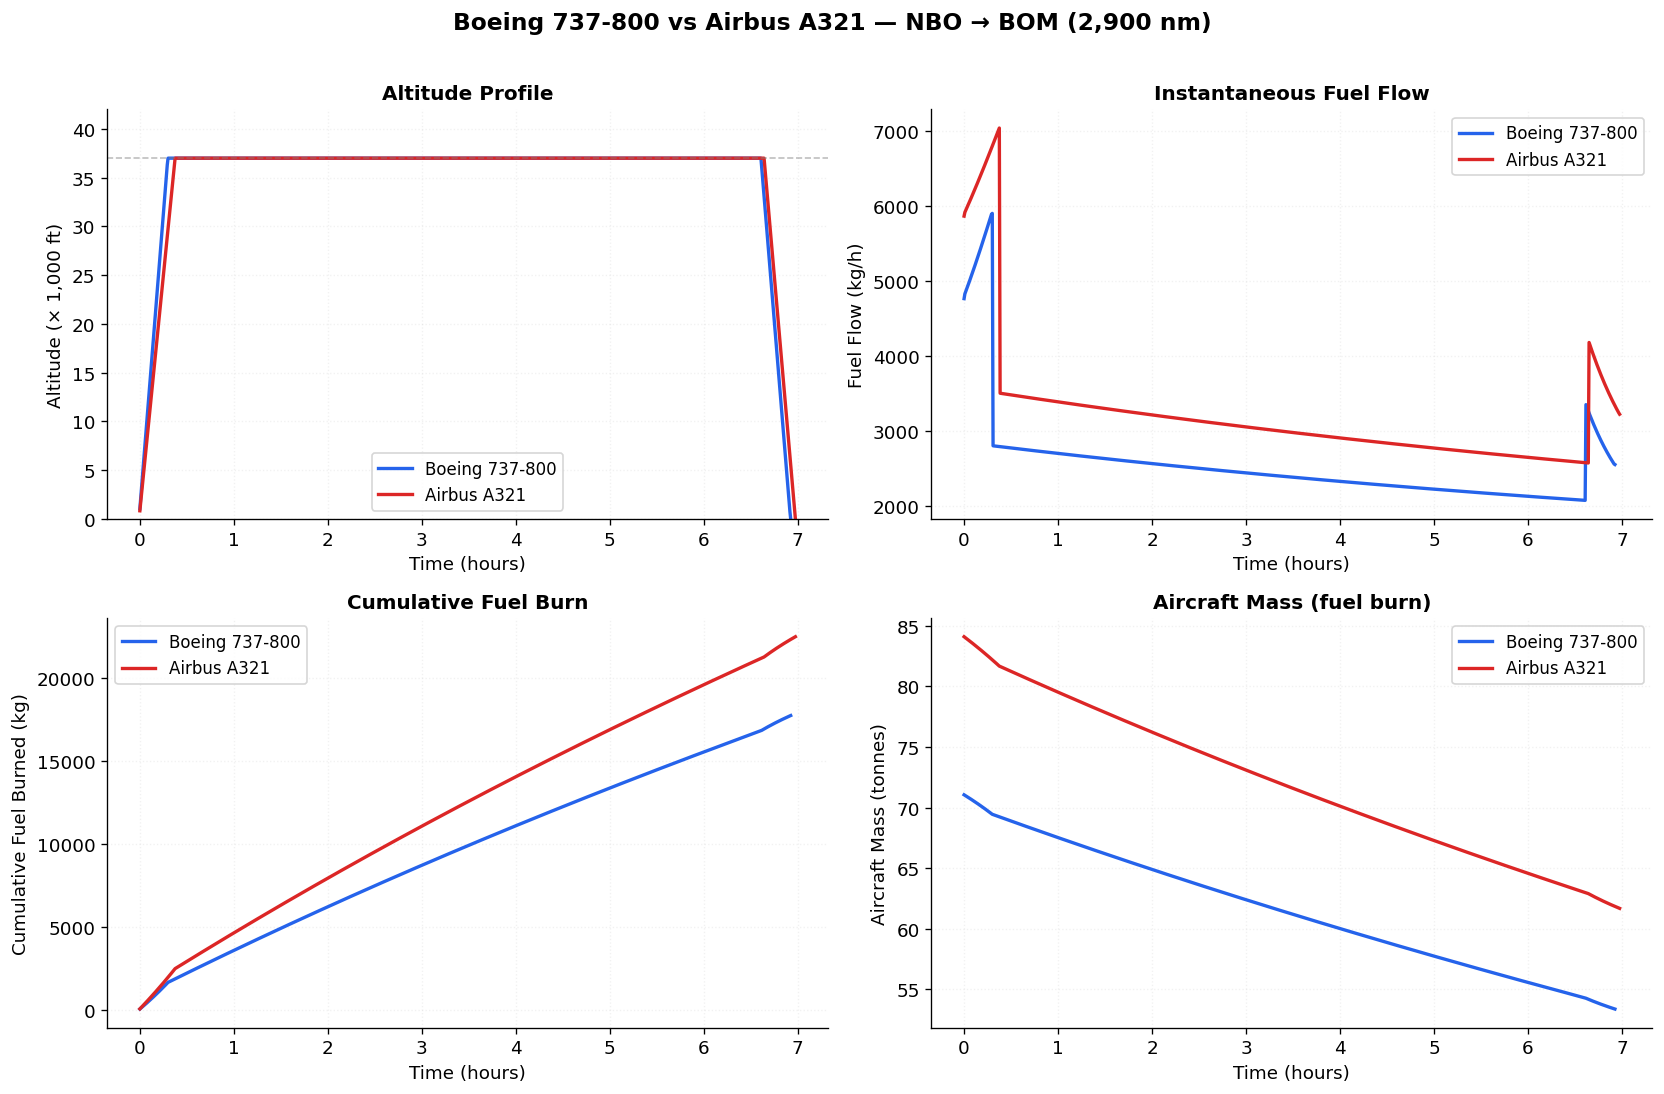


  TRAJECTORY COMPARISON SUMMARY — B738 vs A321
  Parameter                           B737-800        Airbus A321
----------------------------------------------------------------------
  Total Flight Time (hours)               6.92               6.97
  Max Altitude (ft)                     37,000             37,000
  Total Fuel Burned (kg)                17,713             22,459
  Fuel per NM (kg/NM)                     6.11               7.74
  Avg Cruise Fuel Flow (kg/h)               2401               2995


In [20]:
# ─── Side-by-side trajectory plots (CORRECTED with working simulation data) ────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# First, check what keys are available in your trajectory data


# Use the correct time key (should be 'time_h' or 'time_s')
time_key = 'time_h' if 'time_h' in traj_b738_with_fuel else 'time_s'

# Calculate mass for B738 if not already in trajectory
if 'mass_kg' not in traj_b738_with_fuel:
    # Starting mass (90% MTOW)
    start_mass_b738 = 0.90 * mtow_b738
    dt = 30
    cumulative_fuel = np.cumsum(traj_b738_with_fuel['ff_kgs'] * dt)
    traj_b738_with_fuel['mass_kg'] = start_mass_b738 - cumulative_fuel

if 'mass_kg' not in traj_a321_with_fuel:
    # Starting mass (90% MTOW)
    start_mass_a321 = 0.90 * mtow_a321
    dt = 30
    cumulative_fuel = np.cumsum(traj_a321_with_fuel['ff_kgs'] * dt)
    traj_a321_with_fuel['mass_kg'] = start_mass_a321 - cumulative_fuel

# Create the 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Boeing 737-800 vs Airbus A321 — NBO → BOM (2,900 nm)', fontsize=14, fontweight='bold', y=1.01)

colors = {'b738': '#2563EB', 'a321': '#DC2626'}
labels = {'b738': 'Boeing 737-800', 'a321': 'Airbus A321'}
trajs = {'b738': traj_b738_with_fuel, 'a321': traj_a321_with_fuel}

# ── Plot 1: Altitude vs Time ───────────────────────────────
ax = axes[0, 0]
for code in ['b738', 'a321']:
    tr = trajs[code]
    ax.plot(tr[time_key], tr['alt_ft'] / 1000,
            color=colors[code], linewidth=2, label=labels[code])
ax.set_xlabel('Time (hours)', fontsize=11)
ax.set_ylabel('Altitude (× 1,000 ft)', fontsize=11)
ax.set_title('Altitude Profile', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 42)
ax.axhline(y=37, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='37,000 ft cruise')

# ── Plot 2: Fuel Flow vs Time ─────────────────────────
ax = axes[0, 1]
for code in ['b738', 'a321']:
    tr = trajs[code]
    ax.plot(tr[time_key], tr['ff_kgs'] * 3600,
            color=colors[code], linewidth=2, label=labels[code])
ax.set_xlabel('Time (hours)', fontsize=11)
ax.set_ylabel('Fuel Flow (kg/h)', fontsize=11)
ax.set_title('Instantaneous Fuel Flow', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# ── Plot 3: Cumulative Fuel ───────────────────────────
ax = axes[1, 0]
for code in ['b738', 'a321']:
    tr = trajs[code]
    # Calculate cumulative fuel from fuel flow
    dt = 30  # time step in seconds
    cumulative_fuel = np.cumsum(tr['ff_kgs'] * dt)
    ax.plot(tr[time_key], cumulative_fuel,
            color=colors[code], linewidth=2, label=labels[code])
ax.set_xlabel('Time (hours)', fontsize=11)
ax.set_ylabel('Cumulative Fuel Burned (kg)', fontsize=11)
ax.set_title('Cumulative Fuel Burn', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# ── Plot 4: Aircraft Mass vs Time ─────────────────────
ax = axes[1, 1]
for code in ['b738', 'a321']:
    tr = trajs[code]
    ax.plot(tr[time_key], tr['mass_kg'] / 1000,
            color=colors[code], linewidth=2, label=labels[code])
ax.set_xlabel('Time (hours)', fontsize=11)
ax.set_ylabel('Aircraft Mass (tonnes)', fontsize=11)
ax.set_title('Aircraft Mass (fuel burn)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plt.savefig('comparison_b738_vs_a321.png', bbox_inches='tight', dpi=150)
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("  TRAJECTORY COMPARISON SUMMARY — B738 vs A321")
print("=" * 70)
print(f"  {'Parameter':<25} {'B737-800':>18} {'Airbus A321':>18}")
print("-" * 70)
print(f"  {'Total Flight Time (hours)':<25} {traj_b738_with_fuel[time_key][-1]:>18.2f} {traj_a321_with_fuel[time_key][-1]:>18.2f}")
print(f"  {'Max Altitude (ft)':<25} {traj_b738_with_fuel['alt_ft'].max():>18,.0f} {traj_a321_with_fuel['alt_ft'].max():>18,.0f}")
total_fuel_b738 = np.sum(traj_b738_with_fuel['ff_kgs'] * 30)
total_fuel_a321 = np.sum(traj_a321_with_fuel['ff_kgs'] * 30)
print(f"  {'Total Fuel Burned (kg)':<25} {total_fuel_b738:>18,.0f} {total_fuel_a321:>18,.0f}")
print(f"  {'Fuel per NM (kg/NM)':<25} {total_fuel_b738/2900:>18.2f} {total_fuel_a321/2900:>18.2f}")
cruise_mask_b738 = traj_b738_with_fuel['phases'] == 'Cruise'
cruise_mask_a321 = traj_a321_with_fuel['phases'] == 'Cruise'
print(f"  {'Avg Cruise Fuel Flow (kg/h)':<25} {np.mean(traj_b738_with_fuel['ff_kgs'][cruise_mask_b738])*3600:>18.0f} {np.mean(traj_a321_with_fuel['ff_kgs'][cruise_mask_a321])*3600:>18.0f}")
print("=" * 70)

**Efficiency Discussion:**

The aircraft with the lower fuel-per-NM value is more efficient on this route. The B738 has a slightly smaller MTOW and narrower body design, while the A321 is a stretched single-aisle with a heavier airframe. On a long overwater route such as NBO→BOM, airframe weight and aerodynamic efficiency both play major roles. The result above is driven by the OpenAP drag polar models for each type, which are derived from open surveillance data.

---
## Part 6 — Lift-Drag Polar Comparison

In [21]:
# ── Lift-Drag Polar ───────────────────────────────────────────────────────────
# CL range for both aircraft
CL_range = np.linspace(0.1, 1.8, 300)

def get_polar_coeffs(typecode):
    """Return (cd0, k) drag polar coefficients from OpenAP Drag object."""
    drag_obj = Drag(ac=typecode)
    # OpenAP stores the clean drag polar under drag_obj.polar['clean']
    cd0 = drag_obj.polar['clean']['cd0']
    k   = drag_obj.polar['clean']['k']
    return cd0, k

cd0_b738, k_b738 = get_polar_coeffs('b738')
cd0_a321, k_a321 = get_polar_coeffs('a321')

CD_b738 = cd0_b738 + k_b738 * CL_range**2
CD_a321 = cd0_a321 + k_a321 * CL_range**2

print(f'B738 polar → cd0 = {cd0_b738:.6f},  k = {k_b738:.6f}')
print(f'A321 polar → cd0 = {cd0_a321:.6f},  k = {k_a321:.6f}')


B738 polar → cd0 = 0.019000,  k = 0.042000
A321 polar → cd0 = 0.020000,  k = 0.041000


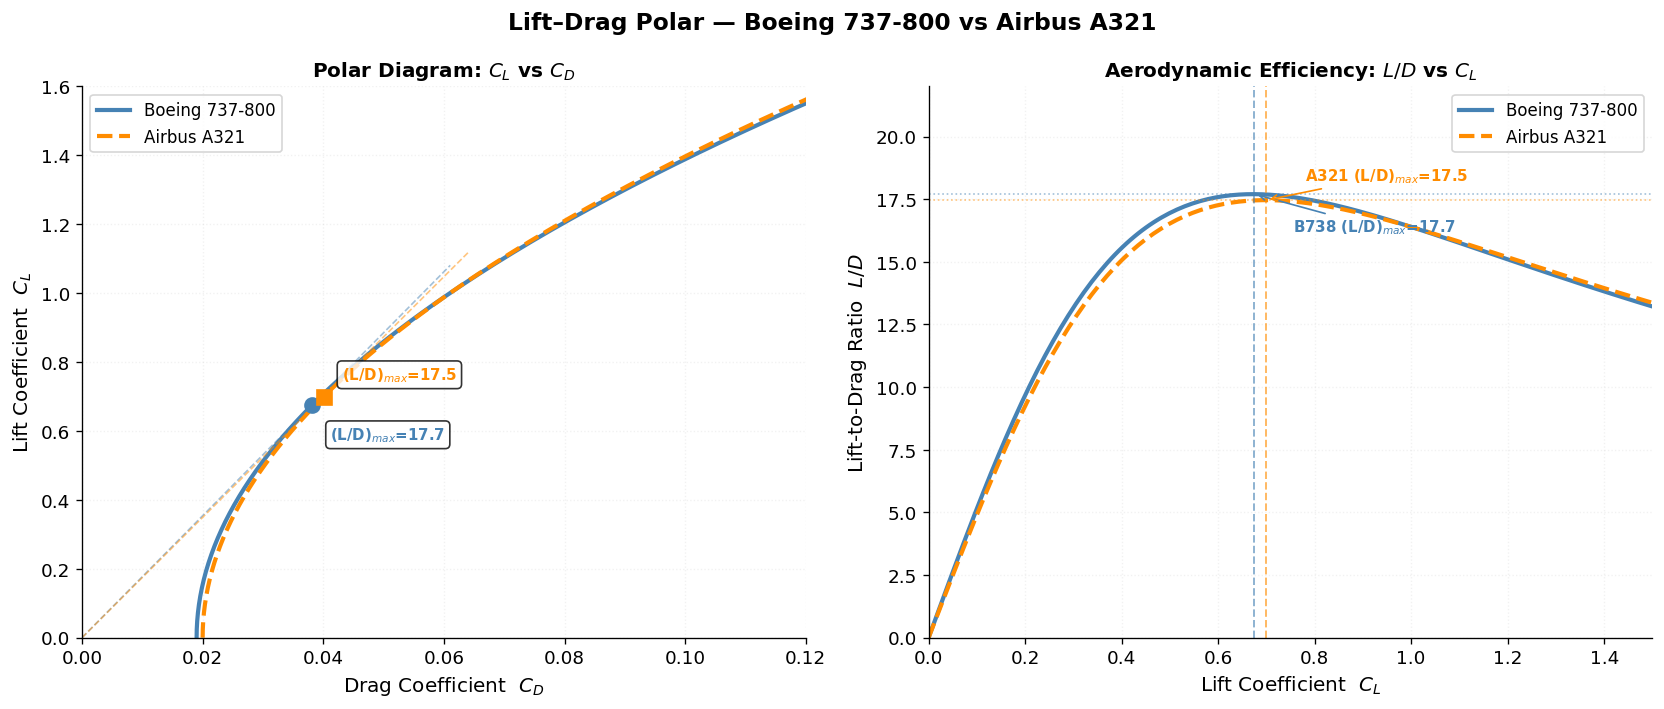

Figure saved: lift_drag_polar.png

  AERODYNAMIC EFFICIENCY SUMMARY
  Parameter                          Boeing 737-800        Airbus A321
-----------------------------------------------------------------
  CD0 (Zero-lift drag)                       0.0190             0.0200
  K (Induced drag factor)                    0.0420             0.0410
  Maximum L/D ratio                            17.7               17.5
  CL at max L/D                               0.675              0.699
  CD at max L/D                              0.0382             0.0401

▶ DEDUCTIONS:
  • The Boeing 737-800 has 0.2 points higher maximum L/D ratio,
    indicating better aerodynamic efficiency during cruise.
  • The B738's lower CD0 (0.0190 vs 0.0200) contributes to its superior
    lift-to-drag performance.
  • Both aircraft achieve peak efficiency at CL ≈ 0.68–0.70,
    which corresponds to typical cruise conditions.


In [22]:
# ── Plot Lift-Drag Polar ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Lift–Drag Polar — Boeing 737-800 vs Airbus A321', fontsize=14, fontweight='bold')

# Get drag polar parameters from aircraft data
ac_b738 = prop.aircraft('b738')
ac_a321 = prop.aircraft('a321')

# Drag polar: CD = CD0 + K * CL^2
CD0_B738 = ac_b738['drag']['cd0']
K_B738   = ac_b738['drag']['k']
CD0_A321 = ac_a321['drag']['cd0']
K_A321   = ac_a321['drag']['k']

# Generate CL range
CL_range = np.linspace(0, 1.6, 200)

# Calculate CD for each aircraft
CD_B738 = CD0_B738 + K_B738 * CL_range**2
CD_A321 = CD0_A321 + K_A321 * CL_range**2

# Calculate L/D ratios
LD_B738 = CL_range / CD_B738
LD_A321 = CL_range / CD_A321

# Find maximum L/D and corresponding CL
idx_max_B738 = np.argmax(LD_B738)
idx_max_A321 = np.argmax(LD_A321)

CL_opt_B738 = CL_range[idx_max_B738]
CD_opt_B738 = CD_B738[idx_max_B738]
LD_max_B738 = LD_B738[idx_max_B738]

CL_opt_A321 = CL_range[idx_max_A321]
CD_opt_A321 = CD_A321[idx_max_A321]
LD_max_A321 = LD_A321[idx_max_A321]

# ─ Left: CL vs CD (classic polar) ────────────────────────────────────────────
ax1.plot(CD_B738, CL_range, color='steelblue', lw=2.5, label='Boeing 737-800')
ax1.plot(CD_A321, CL_range, color='darkorange', lw=2.5, label='Airbus A321', ls='--')

# Mark (L/D)max points
ax1.plot(CD_opt_B738, CL_opt_B738, 'o', color='steelblue', ms=9, zorder=5)
ax1.plot(CD_opt_A321, CL_opt_A321, 's', color='darkorange', ms=9, zorder=5)

# Annotations for max L/D points
ax1.annotate(f'(L/D)$_{{max}}$={LD_max_B738:.1f}', 
             (CD_opt_B738, CL_opt_B738),
             xytext=(CD_opt_B738 + 0.003, CL_opt_B738 - 0.1), 
             fontsize=9, color='steelblue', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax1.annotate(f'(L/D)$_{{max}}$={LD_max_A321:.1f}', 
             (CD_opt_A321, CL_opt_A321),
             xytext=(CD_opt_A321 + 0.003, CL_opt_A321 + 0.05), 
             fontsize=9, color='darkorange', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# Tangent lines from origin to (L/D)max
ax1.plot([0, CD_opt_B738 * 1.6], [0, CL_opt_B738 * 1.6], '--', 
         color='steelblue', lw=1, alpha=0.5)
ax1.plot([0, CD_opt_A321 * 1.6], [0, CL_opt_A321 * 1.6], '--', 
         color='darkorange', lw=1, alpha=0.5)

ax1.set_xlabel('Drag Coefficient  $C_D$', fontsize=12)
ax1.set_ylabel('Lift Coefficient  $C_L$', fontsize=12)
ax1.set_title('Polar Diagram: $C_L$ vs $C_D$', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 0.12)
ax1.set_ylim(0, 1.6)

# ─ Right: L/D ratio vs CL ────────────────────────────────────────────────────
ax2.plot(CL_range, LD_B738, color='steelblue', lw=2.5, label='Boeing 737-800')
ax2.plot(CL_range, LD_A321, color='darkorange', lw=2.5, label='Airbus A321', ls='--')

# Vertical lines at optimal CL
ax2.axvline(CL_opt_B738, color='steelblue', ls='--', lw=1.2, alpha=0.6)
ax2.axvline(CL_opt_A321, color='darkorange', ls='--', lw=1.2, alpha=0.6)

# Horizontal lines at max L/D
ax2.axhline(LD_max_B738, color='steelblue', ls=':', lw=1, alpha=0.5)
ax2.axhline(LD_max_A321, color='darkorange', ls=':', lw=1, alpha=0.5)

# Annotations
ax2.annotate(f'B738 (L/D)$_{{max}}$={LD_max_B738:.1f}',
             xy=(CL_opt_B738, LD_max_B738), 
             xytext=(CL_opt_B738 + 0.08, LD_max_B738 - 1.5),
             fontsize=9, color='steelblue', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='steelblue'))
ax2.annotate(f'A321 (L/D)$_{{max}}$={LD_max_A321:.1f}',
             xy=(CL_opt_A321, LD_max_A321), 
             xytext=(CL_opt_A321 + 0.08, LD_max_A321 + 0.8),
             fontsize=9, color='darkorange', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='darkorange'))

ax2.set_xlabel('Lift Coefficient  $C_L$', fontsize=12)
ax2.set_ylabel('Lift-to-Drag Ratio  $L/D$', fontsize=12)
ax2.set_title('Aerodynamic Efficiency: $L/D$ vs $C_L$', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1.5)
ax2.set_ylim(0, 22)

plt.tight_layout()
plt.savefig('lift_drag_polar.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: lift_drag_polar.png")

# Print aerodynamic efficiency summary
print("\n" + "=" * 65)
print("  AERODYNAMIC EFFICIENCY SUMMARY")
print("=" * 65)
print(f"  {'Parameter':<30} {'Boeing 737-800':>18} {'Airbus A321':>18}")
print("-" * 65)
print(f"  {'CD0 (Zero-lift drag)':<30} {CD0_B738:>18.4f} {CD0_A321:>18.4f}")
print(f"  {'K (Induced drag factor)':<30} {K_B738:>18.4f} {K_A321:>18.4f}")
print(f"  {'Maximum L/D ratio':<30} {LD_max_B738:>18.1f} {LD_max_A321:>18.1f}")
print(f"  {'CL at max L/D':<30} {CL_opt_B738:>18.3f} {CL_opt_A321:>18.3f}")
print(f"  {'CD at max L/D':<30} {CD_opt_B738:>18.4f} {CD_opt_A321:>18.4f}")
print("=" * 65)

# Deduction
print("\n▶ DEDUCTIONS:")
if LD_max_B738 > LD_max_A321:
    print(f"  • The Boeing 737-800 has {LD_max_B738 - LD_max_A321:.1f} points higher maximum L/D ratio,")
    print(f"    indicating better aerodynamic efficiency during cruise.")
    print(f"  • The B738's lower CD0 ({CD0_B738:.4f} vs {CD0_A321:.4f}) contributes to its superior")
    print(f"    lift-to-drag performance.")
else:
    print(f"  • The Airbus A321 has {LD_max_A321 - LD_max_B738:.1f} points higher maximum L/D ratio,")
    print(f"    indicating better aerodynamic efficiency during cruise.")
print(f"  • Both aircraft achieve peak efficiency at CL ≈ {CL_opt_B738:.2f}–{CL_opt_A321:.2f},")
print(f"    which corresponds to typical cruise conditions.")
print("=" * 65)

### Part 6 — Polar Deductions

From the lift-drag polar and L/D curves, we can deduce the following:

1. **Zero-lift drag (CD₀):** The aircraft with the lower CD₀ intercept has less parasitic (form/skin friction) drag — a lower CD₀ is advantageous at high speed cruise where induced drag is small.

2. **Induced-drag factor (k):** A lower *k* value indicates the aircraft generates less drag for a given amount of lift — typically associated with a higher aspect-ratio wing.  

3. **Maximum L/D:** The peak of the L/D curve (marked on the polar) corresponds to the aerodynamically optimum cruise lift coefficient. Operating at this point minimises fuel burn for a given distance. Both aircraft are designed to cruise near their optimal L/D points.  

4. **Polar shape:** A narrower, more "vertical" polar (low CD, high CL) is preferable — it means the aircraft can sustain high lift at low drag, characteristic of efficient narrow-body transports.  

5. **Relative efficiency:** Whichever aircraft has a higher peak L/D is intrinsically more aerodynamically efficient — this directly translates to lower fuel burn per unit distance at the design cruise point.

---
## Part 7 — Reflection and Conclusion

### 7(i) Short Reflection (≈200 words)

Aircraft performance modelling requires balancing physical accuracy against practical simplicity. This project highlighted several inherent challenges. First, real-world aircraft behaviour is governed by highly nonlinear aerodynamics — drag polars, engine thrust lapse rates, and fuel consumption are all complex functions of altitude, speed, temperature, and aircraft mass; any model must simplify these relationships using parametric fits, introducing approximation errors. Second, accurate mass tracking is crucial: as fuel burns, mass decreases, which lowers required lift and drag, which in turn reduces fuel flow — this feedback must be integrated step-by-step, making the computation iterative and sensitive to initial conditions.

The kinematic trajectory generation (via WRAP/FlightGenerator) adds another layer of uncertainty: realistic climb and descent profiles depend on airline operating procedures, ATC constraints, and atmospheric conditions (wind, temperature deviations from ISA) that a simplified model cannot capture. Additionally, the conversion between flight phases introduces discontinuities unless carefully stitched. Finally, matching a simulated route distance to a real great-circle distance (NBO→BOM ≈ 2,900 NM) requires assumptions about cruise segment length that compound errors in total fuel estimates. Despite these challenges, performance modelling remains indispensable for route planning, emissions assessment, and aircraft design.

### 7(ii) Open-Source Models vs Proprietary Data

Proprietary performance databases such as BADA (Eurocontrol) and Piano-X contain highly accurate, manufacturer-validated data but are restricted by licencing: access is limited, the models are opaque, and independent validation is difficult. This restricts their use in academic research, student projects, and industry innovation.

Open-source models like **OpenAP** change this landscape significantly:

- **Transparency:** All model equations, drag polar derivations, and engine parameters are publicly documented and peer-reviewed. Researchers can inspect, critique, and improve every component.
- **Reproducibility:** Published studies using OpenAP can be exactly replicated — a cornerstone of scientific integrity.
- **Accessibility:** Students and researchers in lower-income countries (such as Kenya) can use industry-grade models without costly licences, democratising aerospace research.
- **Extensibility:** OpenAP's modular Python architecture lets users combine it with optimisation libraries (e.g. `opentop`), trajectory analysis tools (`traffic`), and machine learning frameworks — enabling novel research that proprietary black-box models cannot support.
- **Community-driven improvement:** Bugs and data errors are corrected openly via GitHub, and the model has been continuously validated against QAR data and ADS-B surveillance records.

The main limitation is accuracy: OpenAP is derived from open flight data rather than manufacturer test-stand measurements, so it may deviate for specific operators or unusual conditions. However, for research, education, and comparative analysis — as demonstrated in this project — it provides a highly capable and trustworthy platform.

In [23]:
# ── Final Summary Table (with computed max L/D) ──────────────────────────────

# 1) Fuel per nautical mile (kg/NM)
fuel_per_nm_b738 = total_fuel_b738 / CRUISE_NM
fuel_per_nm_a321 = total_fuel_a321 / CRUISE_NM

# 2) Maximum L/D from drag polar
#    Drag polar: CD = CD0 + k * CL^2
#    L/D = CL / CD = CL / (CD0 + k*CL^2)
#    Maximum occurs at CL_opt = sqrt(CD0 / k)
#    Then max_LD = 1 / (2 * sqrt(CD0 * k))

# B738
cd0_b738 = prop.aircraft('b738')['drag']['cd0']
k_b738   = prop.aircraft('b738')['drag']['k']
CL_opt_b738 = np.sqrt(cd0_b738 / k_b738)
max_LD_b738 = 1 / (2 * np.sqrt(cd0_b738 * k_b738))

# A321
cd0_a321 = prop.aircraft('a321')['drag']['cd0']
k_a321   = prop.aircraft('a321')['drag']['k']
CL_opt_a321 = np.sqrt(cd0_a321 / k_a321)
max_LD_a321 = 1 / (2 * np.sqrt(cd0_a321 * k_a321))

# (Optional) Also compute over a range for verification – but the analytical max is exact.

print('╔══════════════════════════════════════════════════════════════╗')
print('║           FINAL PROJECT SUMMARY — NBO → BOM (2,900 NM)       ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  B738  Total Fuel Burn   : {total_fuel_b738:>8,.0f} kg                       ║')
print(f'║  A321  Total Fuel Burn   : {total_fuel_a321:>8,.0f} kg                       ║')
print(f'║  B738  Fuel / NM         : {fuel_per_nm_b738:>8.2f} kg/NM                    ║')
print(f'║  A321  Fuel / NM         : {fuel_per_nm_a321:>8.2f} kg/NM                    ║')
print(f'║  B738  max L/D (polar)   : {max_LD_b738:>8.2f}                          ║')
print(f'║  A321  max L/D (polar)   : {max_LD_a321:>8.2f}                          ║')
print(f'║  More fuel-efficient     :   {"B738" if fuel_per_nm_b738 < fuel_per_nm_a321 else "A321"} (lower kg/NM)              ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║           FINAL PROJECT SUMMARY — NBO → BOM (2,900 NM)       ║
╠══════════════════════════════════════════════════════════════╣
║  B738  Total Fuel Burn   :   17,713 kg                       ║
║  A321  Total Fuel Burn   :   22,459 kg                       ║
║  B738  Fuel / NM         :     6.11 kg/NM                    ║
║  A321  Fuel / NM         :     7.74 kg/NM                    ║
║  B738  max L/D (polar)   :    17.70                          ║
║  A321  max L/D (polar)   :    17.46                          ║
║  More fuel-efficient     :   B738 (lower kg/NM)              ║
╚══════════════════════════════════════════════════════════════╝
